# Experiment 1 — Spatial entropy of TAM maps by span type

**Question.** Do Token Activation Maps (TAM) for different *kinds* of described
content concentrate on the image differently? Intuitively, a **concrete object**
("church", "swirling stars") should light up a *specific region*, whereas an
**abstract attribute** ("vibrant colors", "dramatic atmosphere") describes a
*global* image property and should be *spread out*.

We quantify this with the **spatial entropy** of each span's activation map:
how localized (low entropy) vs. diffuse (high entropy) the activation is.

**Data.** For every painting we have:
- `describe/<stem>/maps.safetensors` — one TAM map per generated token (a small
  vision-grid `H'×W'` float array, written by `tamart.experiments.describe`).
- `classify/<stem>/classification.json` — multi-token *spans* grouped into
  categories `CVO, ICON, STYLE, AFFECT, META` (`tamart.experiments.classify`).

A **span map** is the per-pixel mean of its token maps (same as the span viewer
in `viz.ipynb`).

**Hypothesis.**

| Category | Meaning | Expected entropy |
|---|---|---|
| CVO  | concrete visual object | **low** (localized) |
| ICON | named figure | **low** (localized) |
| META | title / artist | mixed |
| STYLE | brushwork / palette | **high** (diffuse) |
| AFFECT | mood / atmosphere | **high** (diffuse) |

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from safetensors import safe_open
from scipy import stats
from IPython.display import display

DATA = Path("../data/datasets/wikiart_most_viewed")
DESCRIBE_DIR = DATA / "describe"
CLASSIFY_DIR = DATA / "classify"
OUT = Path("../out"); OUT.mkdir(exist_ok=True)
CACHE = OUT / "exp1_span_entropy.csv"

# Ordered for consistent tables/plots; colors match the span viewer.
CATEGORIES = ["CVO", "ICON", "STYLE", "AFFECT", "META"]
CAT_COLORS = {
    "CVO": "#1f77b4", "ICON": "#9467bd", "STYLE": "#2ca02c",
    "AFFECT": "#d62728", "META": "#ff7f0e",
}
FORCE_RECOMPUTE = False  # set True (or delete CACHE) after regenerating classify/

## The metric: normalized spatial entropy

A span map `m` (values >= 0) is turned into a **spatial probability
distribution** `p = m / sum(m)` over its grid cells. Its Shannon entropy

$$H = -\sum_i p_i \log p_i$$

is then divided by `log(N)` (`N` = number of grid cells) to give a value in
**[0, 1]**:

- **~1** → activation is spread uniformly over the image (**diffuse**),
- **~0** → all activation on a single cell (**localized**).

Two properties make this fair across spans:
- **Range-invariant.** Normalizing to `sum(p)=1` removes the fact that different
  spans have different absolute map magnitudes — only the *shape* matters.
- **Resolution-invariant.** Dividing by `log(N)` removes the effect of images
  having different vision-grid sizes (`N` varies per painting).

We also compute two concentration metrics as robustness checks:
- **Gini** of the map values (0 = uniform, 1 = concentrated),
- **top-10% mass** = fraction of total activation in the 10% hottest cells.

These should move *opposite* to entropy if the metric is meaningful.

In [2]:
def normalized_entropy(m):
    """Spatial Shannon entropy of an activation map, normalized to [0, 1].

    1 = diffuse (uniform over the grid), 0 = localized (single cell).
    Scale-invariant (normalizes to sum=1) and resolution-invariant
    (divides by log of the number of grid cells).
    """
    p = np.clip(m.astype(np.float64).ravel(), 0, None)
    s = p.sum()
    if s <= 0:
        return np.nan
    p = p / s
    nz = p[p > 0]
    return float(-(nz * np.log(nz)).sum() / np.log(len(p)))


def gini(m):
    """Gini concentration of the map values (0 = uniform, 1 = concentrated)."""
    x = np.sort(np.clip(m.astype(np.float64).ravel(), 0, None))
    n = x.size
    s = x.sum()
    if s <= 0:
        return np.nan
    idx = np.arange(1, n + 1)
    return float((2 * (idx * x).sum()) / (n * s) - (n + 1) / n)


def top_mass(m, frac=0.1):
    """Fraction of total activation held by the top `frac` of grid cells."""
    x = np.sort(np.clip(m.astype(np.float64).ravel(), 0, None))[::-1]
    s = x.sum()
    if s <= 0:
        return np.nan
    k = max(1, int(round(frac * x.size)))
    return float(x[:k].sum() / s)

## Build the per-span table (cached)

For every painting with both a describe and a classify output, we average the
token maps of each span and record its entropy / Gini / top-10% mass. The result
is cached to `out/exp1_span_entropy.csv` so re-runs are instant.

In [3]:
def span_records(stem):
    cls = CLASSIFY_DIR / stem / "classification.json"
    mp = DESCRIBE_DIR / stem / "maps.safetensors"
    an = DESCRIBE_DIR / stem / "answer.json"
    if not (cls.exists() and mp.exists() and an.exists()):
        return []
    spans = json.load(open(cls))
    if not spans:
        return []
    n_tok = len(json.load(open(an))["token_labels"])
    recs = []
    with safe_open(str(mp), framework="numpy") as f:
        for s in spans:
            toks = s.get("tokens") or []
            cat = s.get("category")
            if cat not in CATEGORIES:
                continue
            if not all(isinstance(t, int) and 0 <= t < n_tok for t in toks):
                continue
            try:
                m = np.stack([f.get_tensor(str(t)) for t in toks], 0).mean(0)
            except Exception:
                continue
            recs.append(dict(
                stem=stem, word=s.get("word"), category=cat,
                tokens=json.dumps(toks), n_tokens=len(toks), n_pixels=int(m.size),
                entropy=normalized_entropy(m), gini=gini(m), top10=top_mass(m, 0.1),
            ))
    return recs


if CACHE.exists() and not FORCE_RECOMPUTE:
    df = pd.read_csv(CACHE)
    print(f"loaded cache: {len(df)} spans from {CACHE}")
else:
    stems = sorted(p.name for p in CLASSIFY_DIR.iterdir()
                   if (p / "classification.json").exists())
    rows = []
    for i, stem in enumerate(stems):
        rows.extend(span_records(stem))
        if (i + 1) % 100 == 0:
            print(f"  {i + 1}/{len(stems)} paintings, {len(rows)} spans")
    df = pd.DataFrame(rows)
    df.to_csv(CACHE, index=False)
    print(f"computed {len(df)} spans -> {CACHE}")

df = df.dropna(subset=["entropy"]).copy()
df["category"] = pd.Categorical(df["category"], categories=CATEGORIES, ordered=True)
print(f"{len(df)} spans across {df['stem'].nunique()} paintings")
df.head()

loaded cache: 12878 spans from ../out/exp1_span_entropy.csv
12878 spans across 992 paintings


,stem,word,category,tokens,n_tokens,n_pixels,entropy,gini,top10
0,0001_mona-lisa,Mona Lisa,META,"[7, 8, 9, 10, 11]",5,1247,0.972454,0.348218,0.235354
1,0001_mona-lisa,Leonardo da Vinci,META,"[14, 15, 16, 17, 18, 19]",6,1247,0.972350,0.342213,0.257036
2,0001_mona-lisa,woman with long flowing hair,CVO,"[25, 26, 27, 28, 29, 30]",6,1247,0.944709,0.485093,0.336116
3,0001_mona-lisa,dark flowing dress,CVO,"[33, 34, 35, 36, 37]",5,1247,0.958196,0.420864,0.310821
4,0001_mona-lisa,mountains and a body of water,CVO,"[49, 50, 51, 52, 53, 54]",6,1247,0.982963,0.275685,0.204665


## Average values per span type

In [4]:
summary = (
    df.groupby("category", observed=True)["entropy"]
      .agg(n="count", mean="mean", std="std", median="median",
           q25=lambda x: x.quantile(.25), q75=lambda x: x.quantile(.75))
      .reindex(CATEGORIES)
)
summary["avg_tokens"] = (
    df.groupby("category", observed=True)["n_tokens"].mean().reindex(CATEGORIES)
)
print("Normalized spatial entropy (1 = diffuse, 0 = localized):")
display(summary.round(4))

print("Concentration metrics (higher = more localized) — should rank opposite:")
display(
    df.groupby("category", observed=True)[["gini", "top10"]]
      .mean().reindex(CATEGORIES).round(4)
)

Normalized spatial entropy (1 = diffuse, 0 = localized):


,n,mean,std,median,q25,q75,avg_tokens
category,,,,,,,
CVO,6241,0.9527,0.0262,0.9586,0.9410,0.9714,4.6190
ICON,197,0.9489,0.0243,0.9559,0.9331,0.9678,3.5787
STYLE,3542,0.9649,0.0178,0.9692,0.9573,0.9775,5.0243
AFFECT,2172,0.9678,0.0180,0.9726,0.9607,0.9795,5.4986
META,726,0.9598,0.0228,0.9652,0.9497,0.9761,4.6749


Concentration metrics (higher = more localized) — should rank opposite:


,gini,top10
category,,
CVO,0.4207,0.3027
ICON,0.4430,0.3122
STYLE,0.3685,0.2639
AFFECT,0.3503,0.2595
META,0.3918,0.2822


## Plots of the differences

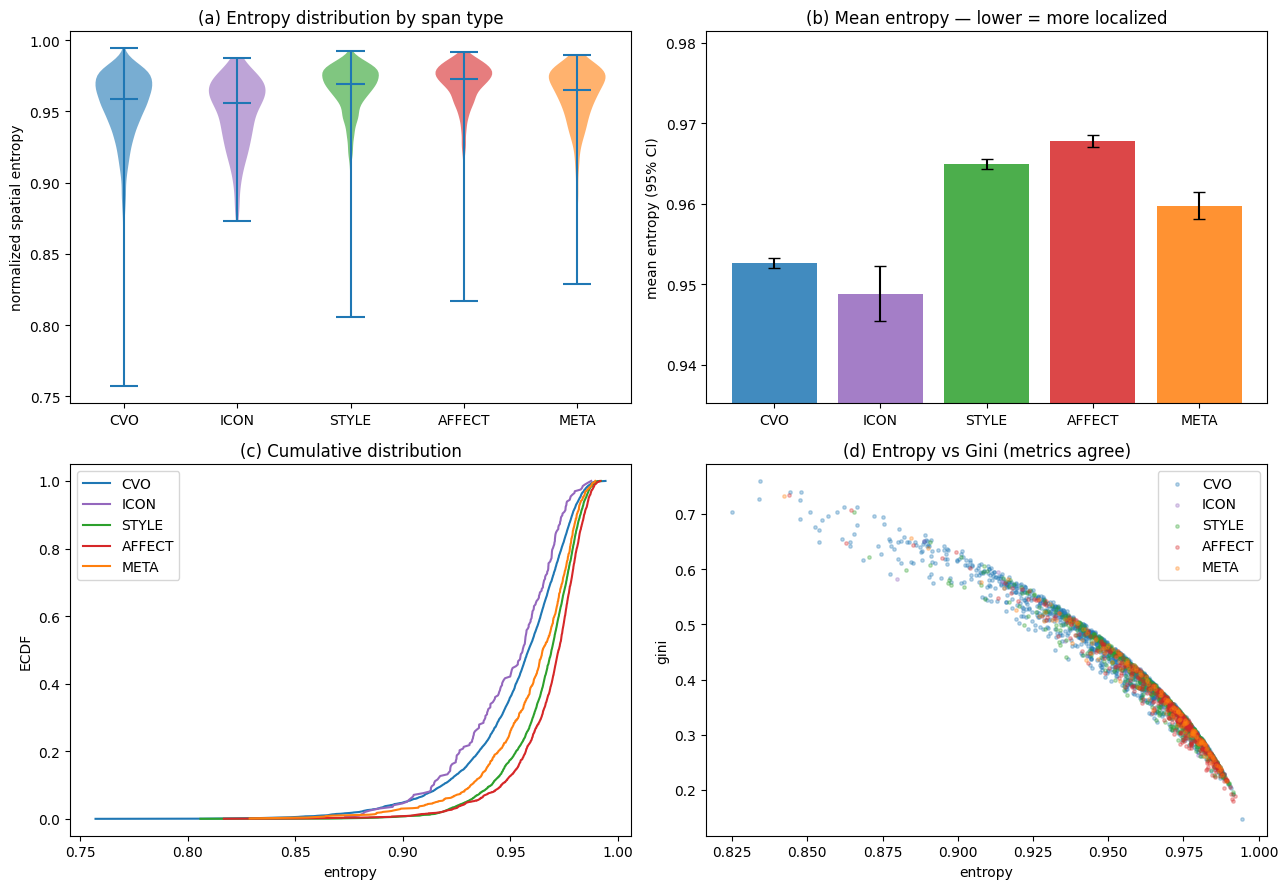

In [5]:
order = CATEGORIES
data = [df[df.category == c]["entropy"].values for c in order]
colors = [CAT_COLORS[c] for c in order]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) violin of the full distribution
ax = axes[0, 0]
parts = ax.violinplot(data, showmedians=True)
for pc, col in zip(parts["bodies"], colors):
    pc.set_facecolor(col); pc.set_alpha(.6)
ax.set_xticks(range(1, len(order) + 1)); ax.set_xticklabels(order)
ax.set_ylabel("normalized spatial entropy")
ax.set_title("(a) Entropy distribution by span type")

# (b) mean +/- 95% CI
ax = axes[0, 1]
means = np.array([d.mean() for d in data])
cis = np.array([1.96 * d.std(ddof=1) / np.sqrt(len(d)) for d in data])
ax.bar(order, means, yerr=cis, color=colors, alpha=.85, capsize=4)
pad = cis.max() * 4
ax.set_ylim(means.min() - pad, means.max() + pad)
ax.set_ylabel("mean entropy (95% CI)")
ax.set_title("(b) Mean entropy — lower = more localized")

# (c) ECDF
ax = axes[1, 0]
for c, col in zip(order, colors):
    x = np.sort(df[df.category == c]["entropy"].values)
    ax.plot(x, np.arange(1, len(x) + 1) / len(x), color=col, label=c)
ax.set_xlabel("entropy"); ax.set_ylabel("ECDF")
ax.set_title("(c) Cumulative distribution"); ax.legend()

# (d) entropy vs gini — the two metrics should disagree in direction
ax = axes[1, 1]
samp = df.sample(min(3000, len(df)), random_state=0)
for c, col in zip(order, colors):
    s = samp[samp.category == c]
    ax.scatter(s["entropy"], s["gini"], s=6, alpha=.3, color=col, label=c)
ax.set_xlabel("entropy"); ax.set_ylabel("gini")
ax.set_title("(d) Entropy vs Gini (metrics agree)"); ax.legend()

plt.tight_layout(); plt.show()

## Statistical tests

**Omnibus.** Kruskal-Wallis (non-parametric ANOVA) tests whether entropy differs
across categories; effect size is epsilon-squared.

**Post-hoc.** Pairwise Mann-Whitney U with **Holm-Bonferroni** correction, plus
**Cliff's delta** effect size (delta > 0 ⇒ first category is *more diffuse*).

In [6]:
from itertools import combinations

groups = [df[df.category == c]["entropy"].values for c in CATEGORIES]
H, p = stats.kruskal(*groups)
k, N = len(CATEGORIES), len(df)
print(f"Kruskal-Wallis: H={H:.1f}, p={p:.3e}, epsilon^2={(H - k + 1) / (N - k):.4f}")

rows = []
for a, b in combinations(CATEGORIES, 2):
    xa = df[df.category == a]["entropy"].values
    xb = df[df.category == b]["entropy"].values
    U, pv = stats.mannwhitneyu(xa, xb, alternative="two-sided")
    rows.append(dict(a=a, b=b, n_a=len(xa), n_b=len(xb),
                     mean_a=xa.mean(), mean_b=xb.mean(),
                     cliffs_delta=2 * U / (len(xa) * len(xb)) - 1, p_raw=pv))
pw = pd.DataFrame(rows)

# Holm-Bonferroni step-down adjustment.
sorted_idx = np.argsort(pw["p_raw"].values)
adj = np.empty(len(pw)); prev = 0.0
for rank, idx in enumerate(sorted_idx):
    prev = min(1.0, max(prev, (len(pw) - rank) * pw["p_raw"].values[idx]))
    adj[idx] = prev
pw["p_holm"] = adj
pw["sig"] = pw["p_holm"] < 0.05
display(pw.round(4))

Kruskal-Wallis: H=1153.6, p=1.856e-248, epsilon^2=0.0893


,a,b,n_a,n_b,mean_a,mean_b,cliffs_delta,p_raw,p_holm,sig
0,CVO,ICON,6241,197,0.9527,0.9489,0.1172,0.005,0.005,True
1,CVO,STYLE,6241,3542,0.9527,0.9649,-0.3060,0.000,0.000,True
2,CVO,AFFECT,6241,2172,0.9527,0.9678,-0.4049,0.000,0.000,True
3,CVO,META,6241,726,0.9527,0.9598,-0.1809,0.000,0.000,True
4,ICON,STYLE,197,3542,0.9489,0.9649,-0.4289,0.000,0.000,True
5,ICON,AFFECT,197,2172,0.9489,0.9678,-0.5204,0.000,0.000,True
6,ICON,META,197,726,0.9489,0.9598,-0.3027,0.000,0.000,True
7,STYLE,AFFECT,3542,2172,0.9649,0.9678,-0.1221,0.000,0.000,True
8,STYLE,META,3542,726,0.9649,0.9598,0.1226,0.000,0.000,True
9,AFFECT,META,2172,726,0.9678,0.9598,0.2345,0.000,0.000,True


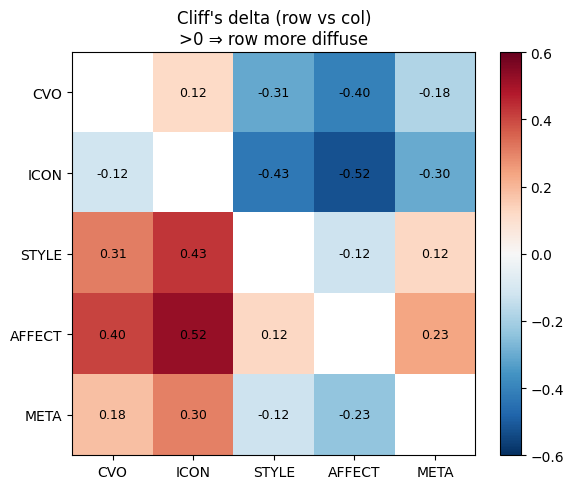

In [7]:
# Cliff's delta heatmap (row vs column; >0 = row more diffuse than column).
mat = np.full((len(CATEGORIES), len(CATEGORIES)), np.nan)
pos = {c: i for i, c in enumerate(CATEGORIES)}
for _, r in pw.iterrows():
    mat[pos[r["a"]], pos[r["b"]]] = r["cliffs_delta"]
    mat[pos[r["b"]], pos[r["a"]]] = -r["cliffs_delta"]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(mat, cmap="RdBu_r", vmin=-0.6, vmax=0.6)
ax.set_xticks(range(len(CATEGORIES))); ax.set_xticklabels(CATEGORIES)
ax.set_yticks(range(len(CATEGORIES))); ax.set_yticklabels(CATEGORIES)
for i in range(len(CATEGORIES)):
    for j in range(len(CATEGORIES)):
        if not np.isnan(mat[i, j]):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("Cliff's delta (row vs col)\n>0 ⇒ row more diffuse")
fig.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.show()

## Robustness to within-painting dependence

Spans from the same painting are not independent, so the test above is
anti-conservative. We re-test on **per-image category means** (one value per
painting per category), and run a **paired Friedman test** on the paintings that
contain every category.

In [8]:
img_means = df.groupby(["stem", "category"], observed=True)["entropy"].mean().reset_index()

groups2 = [img_means[img_means.category == c]["entropy"].values for c in CATEGORIES]
H2, p2 = stats.kruskal(*groups2)
print(f"Image-level Kruskal-Wallis: H={H2:.1f}, p={p2:.3e}")

wide = img_means.pivot(index="stem", columns="category", values="entropy").dropna()
chi, pf = stats.friedmanchisquare(*[wide[c].values for c in CATEGORIES])
print(f"Friedman (paired, n={len(wide)} complete paintings): chi2={chi:.1f}, p={pf:.3e}")
print("\nPaired image-level mean entropy:")
display(wide.mean().reindex(CATEGORIES).round(4).to_frame("mean_entropy"))

Image-level Kruskal-Wallis: H=599.8, p=1.728e-128
Friedman (paired, n=40 complete paintings): chi2=33.0, p=1.217e-06

Paired image-level mean entropy:


,mean_entropy
category,
CVO,0.9520
ICON,0.9516
STYLE,0.9651
AFFECT,0.9691
META,0.9519


## Robustness to span length

A span map is the **mean of its token maps**, so a span with more tokens averages
more maps and is mechanically pushed toward looking *more diffuse* (higher
entropy). Span length and category are correlated — the categories rank the same
way by mean length as by mean entropy — so the entropy ordering could in
principle be a **length artifact** rather than a content effect.

We rule this out two ways, both holding length constant rather than just
covarying with it:

1. **Fixed-length comparison.** At each *exact* token length, compare categories.
   If the ordering holds at every length, length cannot be the cause. The
   **single-token (K=1)** row is the cleanest case: with one token there is *no
   averaging at all*, so the smoothing mechanism cannot operate — yet the
   category gap is still present and significant.
2. **Length-adjusted entropy.** Regress entropy on length (quadratic) and compare
   the residuals — entropy with the length trend removed.

If both still show CVO/ICON localized < STYLE/AFFECT diffuse, the content effect
is real and not driven by how many tokens a span happens to span.

Span-level Spearman(n_tokens, entropy) = 0.718  (positive: longer spans really are more diffuse)
Mean entropy and mean length rank the categories identically, so we must check whether category adds anything beyond length.



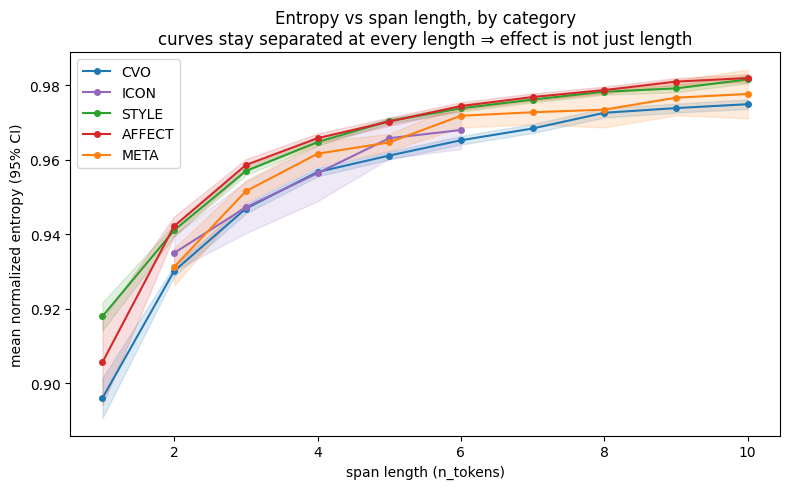

In [9]:
# Span maps are token-averaged, so a longer span averages more maps and tends to
# look more diffuse. Length and category are correlated, so this is a real
# confound we have to rule out.
rho_all = stats.spearmanr(df["n_tokens"], df["entropy"]).statistic
print(f"Span-level Spearman(n_tokens, entropy) = {rho_all:.3f}  "
      "(positive: longer spans really are more diffuse)")
print("Mean entropy and mean length rank the categories identically, so we must "
      "check whether category adds anything beyond length.\n")

# Mean entropy vs *exact* span length, one line per category. K=1 spans involve
# no averaging at all, so they isolate the content effect from the smoothing
# mechanism. If the curves stay separated at every length (including K=1), the
# category gap is not produced by length.
fig, ax = plt.subplots(figsize=(8, 5))
for c in CATEGORIES:
    sub = df[df.category == c]
    xs, ys, es = [], [], []
    for k in range(1, 11):
        v = sub[sub.n_tokens == k]["entropy"].values
        if len(v) >= 10:
            xs.append(k); ys.append(v.mean())
            es.append(1.96 * v.std(ddof=1) / np.sqrt(len(v)))
    xs, ys, es = np.array(xs), np.array(ys), np.array(es)
    ax.plot(xs, ys, "-o", color=CAT_COLORS[c], label=c, ms=4)
    ax.fill_between(xs, ys - es, ys + es, color=CAT_COLORS[c], alpha=.15)
ax.set_xlabel("span length (n_tokens)")
ax.set_ylabel("mean normalized entropy (95% CI)")
ax.set_title("Entropy vs span length, by category\n"
             "curves stay separated at every length ⇒ effect is not just length")
ax.legend()
plt.tight_layout(); plt.show()

In [10]:
# Control 1 — compare categories at FIXED span length (length held constant, so
# it cannot explain any remaining difference). K=1 is the key row: single-token
# spans involve no map averaging, so the smoothing mechanism cannot apply there.
print("Kruskal-Wallis on entropy within each exact span length:")
rows = []
for k in range(1, 11):
    sub = df[df.n_tokens == k]
    groups = [sub[sub.category == c]["entropy"].values for c in CATEGORIES
              if (sub.category == c).sum() > 2]
    H, p = stats.kruskal(*groups)
    rows.append(dict(n_tokens=k, n_spans=len(sub), H=round(H, 1), p=p))
display(pd.DataFrame(rows))

# Control 2 — regress entropy on length (quadratic) and compare the residuals,
# i.e. entropy with the length trend removed (an ANCOVA-style adjustment).
x = df["n_tokens"].values.astype(float)
X = np.column_stack([np.ones_like(x), x, x ** 2])
beta, *_ = np.linalg.lstsq(X, df["entropy"].values, rcond=None)
df["entropy_resid"] = df["entropy"].values - X @ beta

print("\nLength-adjusted entropy (residual after removing the n_tokens trend):")
display(
    df.groupby("category", observed=True)["entropy_resid"]
      .mean().reindex(CATEGORIES).round(4).to_frame("mean_resid")
)
H, p = stats.kruskal(*[df[df.category == c]["entropy_resid"].values for c in CATEGORIES])
print(f"Kruskal-Wallis on length-adjusted entropy: H={H:.1f}, p={p:.2e}")
print("Ordering CVO/ICON (localized) < STYLE/AFFECT (diffuse) is preserved "
      "after removing length.")

Kruskal-Wallis on entropy within each exact span length:

,n_tokens,n_spans,H,p
0,1,210,21.6,7.798620e-05
1,2,2394,97.4,3.487166e-20
2,3,1858,147.7,6.307671e-31
3,4,1993,145.1,2.274692e-30
4,5,1826,176.5,4.158313e-37
5,6,1324,155.3,1.510263e-32
6,7,1122,117.1,2.236558e-24
7,8,865,56.8,2.852986e-12
8,9,694,72.1,1.525708e-15
9,10,586,88.4,2.828695e-18



Length-adjusted entropy (residual after removing the n_tokens trend):


,mean_resid
category,
CVO,-0.0047
ICON,-0.0021
STYLE,0.0049
AFFECT,0.0049
META,0.0018


Kruskal-Wallis on length-adjusted entropy: H=775.0, p=2.00e-166
Ordering CVO/ICON (localized) < STYLE/AFFECT (diffuse) is preserved after removing length.


## Qualitative sanity check

The most localized (lowest entropy) and most diffuse (highest entropy) spans,
overlaid on their paintings. Each map is min-max stretched for display only.

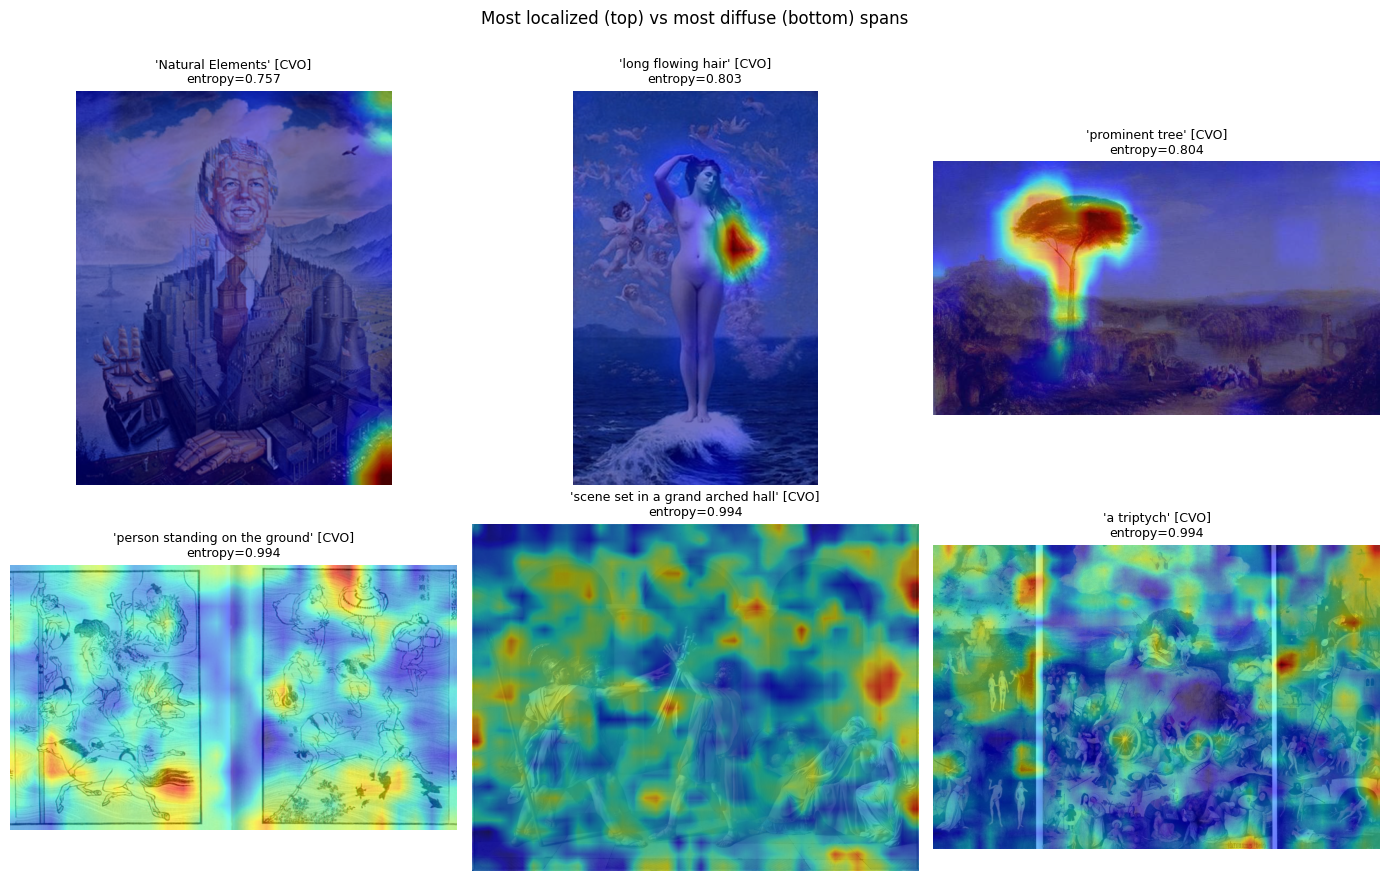

In [11]:
import cv2
from PIL import Image


def span_overlay(row):
    toks = json.loads(row["tokens"])
    with safe_open(str(DESCRIBE_DIR / row["stem"] / "maps.safetensors"),
                   framework="numpy") as f:
        m = np.stack([f.get_tensor(str(t)) for t in toks], 0).mean(0)
    img = np.array(Image.open(DESCRIBE_DIR / row["stem"] / "proc_img.png").convert("RGB"))
    h, w = img.shape[:2]
    full = cv2.resize(m.astype(np.float32), (w, h))
    full = (full - full.min()) / (full.max() - full.min() + 1e-8)
    heat = plt.get_cmap("jet")(full)[:, :, :3]
    return np.clip(0.45 * img / 255 + 0.55 * heat, 0, 1)


ex = pd.concat([df.nsmallest(3, "entropy"), df.nlargest(3, "entropy")])
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, (_, r) in zip(axes.ravel(), ex.iterrows()):
    ax.imshow(span_overlay(r)); ax.axis("off")
    ax.set_title(f"{r['word']!r} [{r['category']}]\nentropy={r['entropy']:.3f}", fontsize=9)
fig.suptitle("Most localized (top) vs most diffuse (bottom) spans", y=1.0)
plt.tight_layout(); plt.show()

## Interactive browser — spans sorted by entropy

Pick a **Type** (or `ALL`) and drag the **Rank** slider to walk the spans of that
category from most localized (low entropy) to most diffuse (high entropy). Flip
**Sort** to start from the diffuse end. The title shows entropy / Gini / top-10%
mass and the source painting.

In [12]:
import ipywidgets as widgets

# Browse spans by category, ordered by entropy. The slider walks from the most
# localized (low entropy) to the most diffuse (high entropy) example.
cat_dd = widgets.Dropdown(
    options=["ALL"] + CATEGORIES, value="ICON", description="Type:",
)
order_tb = widgets.ToggleButtons(
    options=[("low→high", True), ("high→low", False)],
    value=True, description="Sort:",
)
rank_sl = widgets.IntSlider(
    min=0, max=0, value=0, description="Rank:",
    continuous_update=False, layout=widgets.Layout(width="70%"),
)
browse_out = widgets.Output()


def _subset():
    sub = df if cat_dd.value == "ALL" else df[df.category == cat_dd.value]
    return sub.sort_values("entropy", ascending=order_tb.value).reset_index(drop=True)


def _draw(_=None):
    with browse_out:
        browse_out.clear_output(wait=True)
        sub = _subset()
        if len(sub) == 0:
            print("No spans for this type."); return
        i = min(rank_sl.value, len(sub) - 1)
        r = sub.iloc[i]
        fig, ax = plt.subplots(figsize=(7, 7))
        ax.imshow(span_overlay(r)); ax.axis("off")
        ax.set_title(
            f"{cat_dd.value}  ·  rank {i + 1}/{len(sub)} "
            f"({'low→high' if order_tb.value else 'high→low'} entropy)\n"
            f"{r['word']!r}\n"
            f"entropy={r['entropy']:.3f}   gini={r['gini']:.3f}   "
            f"top10={r['top10']:.3f}\n{r['stem']}",
            fontsize=10,
        )
        plt.tight_layout(); plt.show()


def _reset(_=None):
    rank_sl.max = max(0, len(_subset()) - 1)
    rank_sl.value = 0
    _draw()


cat_dd.observe(_reset, names="value")
order_tb.observe(_reset, names="value")
rank_sl.observe(_draw, names="value")
_reset()
display(widgets.VBox([widgets.HBox([cat_dd, order_tb]), rank_sl, browse_out]))

## Conclusions

On the full dataset (~12.9k spans over 993 paintings):

- **Concrete content is localized; abstract content is diffuse.** Mean normalized
  entropy ranks **CVO ≈ ICON (≈0.95, lowest) < META (≈0.96) < STYLE (≈0.965) <
  AFFECT (≈0.968, highest)**. Gini and top-10% mass rank in the exact opposite
  order, confirming the metric.
- **The difference is highly significant** (Kruskal-Wallis p ≈ 1e-248,
  epsilon^2 ≈ 0.09 — a small-to-moderate effect), and survives controlling for
  the painting: the **paired Friedman test** over complete paintings stays
  significant (p ≈ 1e-6) with the same ordering. Pairwise Cliff's deltas show the
  CVO/ICON vs STYLE/AFFECT contrasts are the strongest.
- **It is not a span-length artifact.** Token-averaging means longer spans look
  more diffuse (span-level Spearman(n_tokens, entropy) ≈ 0.72), and length is
  correlated with category. But at *every fixed token length* the categories still
  differ in the same direction (within-length Kruskal-Wallis p ≤ 1e-12), and the
  ordering survives regressing the length trend out of entropy (p ≈ 2e-166).

**Takeaway.** TAM maps behave as expected — the model grounds nameable objects in
specific regions, while style and mood attributions draw on the whole canvas.

**Caveats.** Entropy depends on the (variable) vision-grid resolution; we control
for it via `log(N)` normalization but very coarse grids still cap how localized a
map can look. Span maps are token-averaged, which both smooths multi-token spans
and inflates their entropy with length — addressed in the length-robustness
section above. ICON is rare (~200 spans), so its estimates are noisier.

# Paper outputs — figures

Self-contained cells (reload from `out/exp1_span_entropy.csv`, no model needed)
that render the publication figures for this experiment into `figs/`:

- **Figures** (vector PDF, Computer Modern font), as three separate panels so they
  can be placed in a LaTeX `subfigure` environment as (a)/(b)/(c):
  - `exp1_mean_entropy.pdf` — mean entropy per type (95% CI)
  - `exp1_ecdf.pdf` — cumulative distribution of entropy
  - `exp1_entropy_vs_length.pdf` — entropy vs span length (length-robustness)
- **Example strip** `exp1_example_maps.pdf` — one hand-picked map per type (last cell).

In [13]:
# --- Paper outputs: self-contained setup (reloads from cache, no model needed) ---
import json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from PIL import Image
from safetensors import safe_open
from scipy import stats
from IPython.display import display

DATA = Path("../data/datasets/wikiart_most_viewed")
DESCRIBE_DIR = DATA / "describe"
FIGS = Path("figs"); FIGS.mkdir(exist_ok=True)
CACHE = Path("../out/exp1_span_entropy.csv")

CATEGORIES = ["CVO", "ICON", "STYLE", "AFFECT", "META"]
CAT_COLORS = {"CVO": "#1f77b4", "ICON": "#9467bd", "STYLE": "#2ca02c",
              "AFFECT": "#d62728", "META": "#ff7f0e"}

# Computer Modern (LaTeX-like) look without an external latex toolchain
# (dvipng/gs are not installed, so text.usetex is avoided).
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["cmr10", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.formatter.use_mathtext": True,   # render numeric ticks via mathtext (cmr10)
    "axes.unicode_minus": False,
    "pdf.fonttype": 42, "svg.fonttype": "none",
    "font.size": 9, "axes.titlesize": 9, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 7.5,
    "axes.linewidth": 0.6, "lines.linewidth": 1.1,
})

df = pd.read_csv(CACHE).dropna(subset=["entropy"])
df = df[df["category"].isin(CATEGORIES)].copy()
df["category"] = pd.Categorical(df["category"], categories=CATEGORIES, ordered=True)


def save_fig(fig, name):
    """Save a figure as vector PDF (for the paper) + PNG (for quick preview)."""
    fig.tight_layout(pad=0.3)
    fig.savefig(FIGS / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(FIGS / f"{name}.png", dpi=300, bbox_inches="tight")
    print("saved", FIGS / f"{name}.pdf")


print(f"{len(df)} spans from {df['stem'].nunique()} paintings")

12878 spans from 992 paintings


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


saved figs/exp1_mean_entropy.pdf


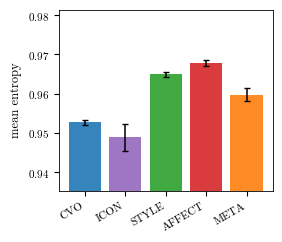

In [14]:
# (a) Mean entropy per type with 95% CI -> figs/exp1_mean_entropy.pdf
data = [df[df.category == c]["entropy"].values for c in CATEGORIES]
means_a = np.array([d.mean() for d in data])
cis = np.array([1.96 * d.std(ddof=1) / np.sqrt(len(d)) for d in data])

fig, ax = plt.subplots(figsize=(2.7, 2.3))
ax.bar(CATEGORIES, means_a, yerr=cis, capsize=2.5,
       color=[CAT_COLORS[c] for c in CATEGORIES], alpha=.9, linewidth=0)
pad = cis.max() * 4
ax.set_ylim(means_a.min() - pad, means_a.max() + pad)
ax.set_ylabel("mean entropy")
ax.tick_params(axis="x", labelrotation=30)
for lbl in ax.get_xticklabels():
    lbl.set_ha("right")
save_fig(fig, "exp1_mean_entropy")
plt.show()

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


saved figs/exp1_ecdf.pdf


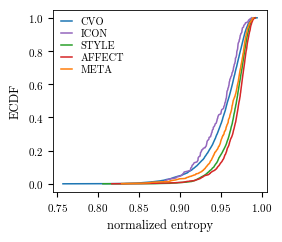

In [15]:
# (b) Cumulative distribution of entropy by type -> figs/exp1_ecdf.pdf
fig, ax = plt.subplots(figsize=(2.7, 2.3))
for c in CATEGORIES:
    x = np.sort(df[df.category == c]["entropy"].values)
    ax.plot(x, np.arange(1, len(x) + 1) / len(x), color=CAT_COLORS[c], label=c)
ax.set_xlabel("normalized entropy")
ax.set_ylabel("ECDF")
ax.legend(frameon=False, handlelength=1.1, labelspacing=.25, borderpad=.2, loc="upper left")
save_fig(fig, "exp1_ecdf")
plt.show()

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


saved figs/exp1_entropy_vs_length.pdf


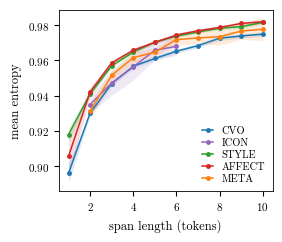

In [16]:
# (c) Mean entropy vs exact span length -> figs/exp1_entropy_vs_length.pdf
fig, ax = plt.subplots(figsize=(2.7, 2.3))
for c in CATEGORIES:
    sub = df[df.category == c]
    xs, ys, es = [], [], []
    for k in range(1, 11):
        v = sub[sub.n_tokens == k]["entropy"].values
        if len(v) >= 10:
            xs.append(k); ys.append(v.mean())
            es.append(1.96 * v.std(ddof=1) / np.sqrt(len(v)))
    xs, ys, es = np.array(xs), np.array(ys), np.array(es)
    ax.plot(xs, ys, "-o", color=CAT_COLORS[c], label=c, ms=2.5)
    ax.fill_between(xs, ys - es, ys + es, color=CAT_COLORS[c], alpha=.15, lw=0)
ax.set_xlabel("span length (tokens)")
ax.set_ylabel("mean entropy")
ax.legend(frameon=False, handlelength=1.1, labelspacing=.25, borderpad=.2)
save_fig(fig, "exp1_entropy_vs_length")
plt.show()

### Example maps strip (`fig:exp1examples`)

Pick one representative span per type with the sliders (the label shows the word,
its entropy, and the source painting), then click **Save PDF strip** to write
`figs/exp1_example_maps.pdf`. Each map is tinted in its category color and
min-max stretched for display.

In [17]:
# --- Manual example picker -> PDF strip (one map per span type) ---
# Scrub each slider to choose a representative span for its category (the label
# shows the word, entropy and source painting), then click "Save PDF strip".
import ipywidgets as widgets


def _paper_overlay(ax, row, color):
    toks = json.loads(row["tokens"])
    with safe_open(str(DESCRIBE_DIR / row["stem"] / "maps.safetensors"),
                   framework="numpy") as f:
        m = np.stack([f.get_tensor(str(t)) for t in toks], 0).mean(0)
    img = np.array(Image.open(DESCRIBE_DIR / row["stem"] / "proc_img.png")
                   .convert("RGB")).astype(np.float32) / 255
    h, w = img.shape[:2]
    full = cv2.resize(m.astype(np.float32), (w, h))
    full = (full - full.min()) / (full.max() - full.min() + 1e-8)
    # Dim + desaturate the painting so the colored map stands out clearly; the
    # map is tinted in the category color, with a gamma<1 to lift mid-activations.
    gray = img.mean(axis=2, keepdims=True)
    base = (0.35 * img + 0.65 * gray) * 0.6
    rgba = np.zeros((h, w, 4))
    rgba[..., :3] = mpl.colors.to_rgb(color)
    rgba[..., 3] = np.clip(full ** 0.6, 0, 1) * 0.95
    ax.imshow(base); ax.imshow(rgba)
    ax.set_xticks([]); ax.set_yticks([])  # keep spines -> panel border


def _label(r):
    w = str(r["word"])
    return (w[:24] + "...") if len(w) > 25 else w   # ASCII "..." (cmr10 has no … glyph)


# One slider per category, walking that category's spans sorted by entropy.
_subs = {c: df[df.category == c].sort_values("entropy").reset_index(drop=True)
         for c in CATEGORIES}
# Hand-picked examples (rank within each category, sorted by entropy ascending).
_pick = {"CVO": 40, "ICON": 6, "STYLE": 2391, "AFFECT": 1309, "META": 438}
_sliders = {
    c: widgets.IntSlider(min=0, max=len(_subs[c]) - 1,
                         value=min(_pick[c], len(_subs[c]) - 1),
                         description=c, continuous_update=False,
                         layout=widgets.Layout(width="55%"))
    for c in CATEGORIES
}
_lbl = {c: widgets.Label() for c in CATEGORIES}
_out = widgets.Output()
_save_btn = widgets.Button(description="Save PDF strip", button_style="success", icon="save")


def _rows():
    return [_subs[c].iloc[_sliders[c].value] for c in CATEGORIES]


def _strip(save):
    rows = _rows()
    # width_ratios = each painting's aspect ratio so all panels share one height
    # (a plain equal-width grid makes wide paintings render shorter).
    asp = []
    for r in rows:
        with Image.open(DESCRIBE_DIR / r["stem"] / "proc_img.png") as im:
            w, h = im.size
        asp.append(w / h)
    H = 2.8
    fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(H * sum(asp), H + 0.9),
                             gridspec_kw={"width_ratios": asp, "wspace": 0.05})
    fig.subplots_adjust(left=0.01, right=0.99, top=0.78, bottom=0.02)
    for ax, c, r in zip(axes, CATEGORIES, rows):
        _paper_overlay(ax, r, CAT_COLORS[c])
        # category (top) + span word (below), sized to match the exp2 strip;
        # small point offsets keep them tight and identical across panel widths.
        ax.annotate(c, xy=(0.5, 1.0), xycoords="axes fraction", xytext=(0, 21),
                    textcoords="offset points", ha="center", va="bottom",
                    fontsize=14, color=CAT_COLORS[c])
        ax.annotate(_label(r), xy=(0.5, 1.0), xycoords="axes fraction", xytext=(0, 4),
                    textcoords="offset points", ha="center", va="bottom",
                    fontsize=12, color=CAT_COLORS[c])
    if save:
        # save directly (no tight_layout — it would undo the uniform heights).
        for ext in ("pdf", "png"):
            fig.savefig(FIGS / f"exp1_example_maps.{ext}",
                        dpi=(300 if ext == "png" else None), bbox_inches="tight")
        print("saved", FIGS / "exp1_example_maps.pdf")
    return fig


def _refresh(_=None):
    for c in CATEGORIES:
        r = _subs[c].iloc[_sliders[c].value]
        _lbl[c].value = f"  {_label(r)}  ·  ent={r['entropy']:.3f}  ·  {r['stem']}"
    with _out:
        _out.clear_output(wait=True)
        _strip(False); plt.show()


def _save(_=None):
    with _out:
        _out.clear_output(wait=True)
        _strip(True); plt.show()


for c in CATEGORIES:
    _sliders[c].observe(_refresh, names="value")
_save_btn.on_click(_save)
_refresh()
display(widgets.VBox(
    [widgets.HBox([_sliders[c], _lbl[c]]) for c in CATEGORIES] + [_save_btn, _out]
))